# Comprehensive Guide to Data Normalization (Min-Max Scaling)

## 1. What is Normalization?
Normalization is a data preprocessing technique used to rescale numeric features to a specific, fixed range—most commonly **0 to 1** (or sometimes -1 to 1). Unlike Standardization (which centers data around a mean of 0 and standard deviation of 1), Normalization bounds the data within a strict minimum and maximum limit.

---

## 2. The Mathematical Formula
For any individual feature (column), each raw data point $x$ is transformed into $x_{scaled}$ using the following formula:

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

### Component Breakdown:
*   **$x$**: The original raw value of the data point.
*   **$x_{min}$**: The minimum value found within that specific feature column.
*   **$x_{max}$**: The maximum value found within that specific feature column.
*   **Range ($x_{max} - x_{min}$)**: The denominator represents the total spread of the feature.

### Custom Range Formula:
If you want to scale data between a custom minimum ($a$) and maximum ($b$) instead of 0 and 1, the formula adapts to:

$$x_{scaled} = a + \frac{(x - x_{min}) \cdot (b - a)}{x_{max} - x_{min}}$$

---

## 3. Core Attributes in Scikit-Learn (`MinMaxScaler`)
When you use `MinMaxScaler` in Python, scikit-learn calculates and stores the properties of your data during the `.fit()` step. You can inspect these attributes directly:

*   **`scaler.data_min_`**: An array containing the minimum value (`x_min`) for each feature.
*   **`scaler.data_max_`**: An array containing the maximum value (`x_max`) for each feature.
*   **`scaler.data_range_`**: An array containing the feature range (`x_max - x_min`) for each feature.
*   **`scaler.scale_`**: The relative scaling factor applied to the data, calculated as `(max - min) / (data_max_ - data_min_)`.

---

## 4. Key Characteristics & When to Use It

### Ideal Scenarios for Normalization:
*   **Distance-Based Algorithms**: Algorithms like **K-Nearest Neighbors (KNN)** and **K-Means Clustering** rely heavily on distance metrics (like Euclidean distance). If one feature has a range of 0–1 and another has 0–1,000,000, the larger feature will completely dominate the distance calculation.
*   **Artificial Neural Networks (ANNs)**: Deep learning models often converge much faster when inputs are scaled to a strict [0, 1] or [-1, 1] range, preventing gradients from exploding.
*   **Image Processing**: Pixel values naturally range from 0 to 255. Normalizing them to a 0–1 range is standard practice before feeding them into Convolutional Neural Networks (CNNs).
*   **Non-Gaussian Distributions**: Normalization is highly effective when you know your data does *not* follow a normal (bell-curve) distribution.

---

## 5. Major Limitations & Weaknesses

*   **Extreme Vulnerability to Outliers**: Because the formula relies directly on $x_{min}$ and $x_{max}$, a single extreme outlier will crush the rest of your data into a tiny, squished range.
    *   *Example:* If 99% of your data lies between 10 and 20, but one outlier is 1,000, the values between 10 and 20 will all compress into a virtually indistinguishable cluster near 0.01.
*   **Destruction of Variance Information**: It compresses the distribution into a tight box, which might suppress the natural variance structure that certain machine learning algorithms need.


In [17]:
import matplotlib.pyplot as plt
import numpy as np  # linear algebra
import pandas as pd  # data processing
import seaborn as sns


---

# Practical walk-through

## Step 1 — Load the dataset

We use the classic **Wine** dataset. The file has no header row, so we pass `header=None` and keep only
the first three columns with `usecols=[0, 1, 2]`:

* **Class label** — the wine cultivar (1, 2 or 3). This is the target, not a feature.
* **Alcohol** — roughly 11 – 15 (% by volume).
* **Malic acid** — roughly 0.7 – 5.8 (g/L).

These two features are on different scales *and* have very different spreads, which is exactly the
situation Min-Max scaling is meant to fix.

In [18]:
# no header row in the file, so name the columns ourselves; keep only 2 features + the class label
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']

In [19]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


## Step 2 — Look at the raw distributions first

Before scaling anything, always inspect the features. Two things to check here:

1. **The ranges**: `Alcohol` is centred around 13 with a narrow spread, while `Malic acid` lives between
   ~0.7 and ~5.8. They are not comparable as-is.
2. **The shapes**: `Alcohol` is fairly symmetric, `Malic acid` is clearly **right-skewed**. Remember that
   Min-Max scaling squeezes the values into [0, 1] but leaves the skew exactly as it is.

The scatter plot then shows the same point in the feature space a distance-based model would actually see.

<Axes: xlabel='Alcohol', ylabel='Density'>

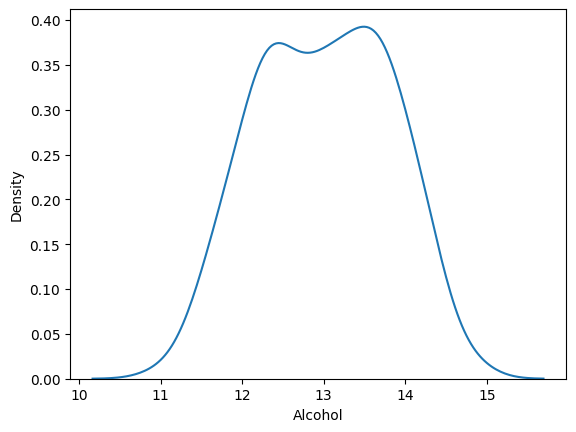

In [20]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

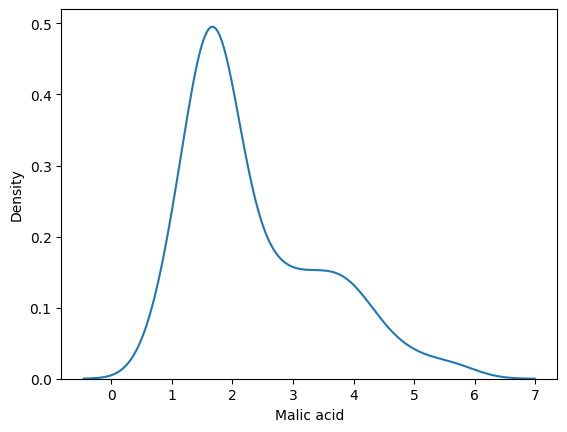

In [21]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

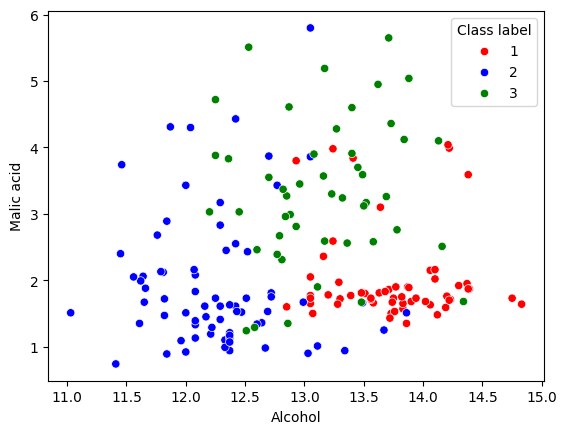

In [22]:
color_dict = {1: 'red', 3: 'green', 2: 'blue'}
sns.scatterplot(data=df, x='Alcohol', y='Malic acid', hue='Class label', palette=color_dict)


## Step 3 — Train / test split (BEFORE scaling)

**Why split first?** To avoid **data leakage**.

The scaler learns `x_min` and `x_max` from the data. If we scaled the full dataset and split afterwards,
those extremes could come from rows that later end up in the test set — so the model would be evaluated
using information it should never have had, and the score would be optimistically biased.

The correct order is always:

1. **Split** into train and test.
2. **`fit`** the scaler on the **training set only** — this is where `x_min` and `x_max` are learned.
3. **`transform`** both train and test using those *same* learned values.

One consequence worth knowing: because the test set is transformed with the *training* min/max, test
values can legitimately fall slightly **outside** [0, 1] (e.g. `-0.03` or `1.04`) if the test set contains
a value more extreme than anything seen during training. That is expected and correct — do not "fix" it
by re-fitting on the test set.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

## Step 4 — Apply `MinMaxScaler`

`MinMaxScaler` implements $x_{scaled} = \dfrac{x - x_{min}}{x_{max} - x_{min}}$ column by column.

**`fit` vs `transform` vs `fit_transform`:**

| Method | What it does | Use it on |
|---|---|---|
| `fit(X)` | *Learns* and stores `data_min_`, `data_max_`, `data_range_` and `scale_` per column. | Training set only |
| `transform(X)` | *Applies* the stored formula to the data. | Train **and** test |
| `fit_transform(X)` | Convenience: fit then transform in one call. | Training set only |

`MinMaxScaler(feature_range=(a, b))` lets you target a custom interval instead of the default `(0, 1)` —
for example `(-1, 1)` is a common choice for neural networks with `tanh` activations.

Note that `transform()` returns a **NumPy array**, so the column names are lost; we rebuild the DataFrames
in the next cell.

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Inspecting the parameters the scaler learned

These are the `x_min`, `x_max` and range from the formula — one value per column, all computed **from the
training set only**. They are exactly what will be reused to transform the test set and any future data.

In [25]:
# the statistics learned during .fit() -- computed on X_train only
scaler.data_min_, scaler.data_max_, scaler.data_range_, scaler.scale_

(array([11.03,  0.89]),
 array([14.75,  5.65]),
 array([3.72, 4.76]),
 array([0.2688172 , 0.21008403]))

In [26]:
# transform() returns a NumPy array, so rebuild DataFrames to get the column names back
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

## Step 5 — Verify the result with `describe()`

This is the numerical proof that normalization worked. Compare the two tables:

* **Before**: `Alcohol` runs 11.0 – 14.8, `Malic acid` runs 0.9 – 5.6, with very different means and stds.
* **After**: **both** columns have `min = 0.0` and `max = 1.0`.

Notice what did *not* happen: the means are **not** 0 and the stds are **not** 1 (that is what
standardization gives you). And the mean of `Malic acid` sits near 0.3 rather than 0.5 — proof that the
right-skew we saw earlier survived the transformation untouched.

In [27]:
# BEFORE scaling: different ranges, different means, different spreads
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [28]:
# AFTER scaling: min = 0 and max = 1 for every column (mean/std are NOT standardised)
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


## Step 6 — Effect of scaling on the feature space

Plotting the two features against each other before and after normalization shows the essential idea:

* **Before**: the axes have different ranges, so the feature with the wider spread dominates any
  Euclidean distance computation — the classes look separated mostly along one direction.
* **After**: both axes run exactly 0 to 1, so the two features contribute **equally** to distance.

Crucially, the **shape of the point cloud is identical** in both plots, and the colours (classes) stay in
the same relative arrangement. Min-Max scaling is a linear transformation: it moves and rescales the
axes, it never distorts the geometry.

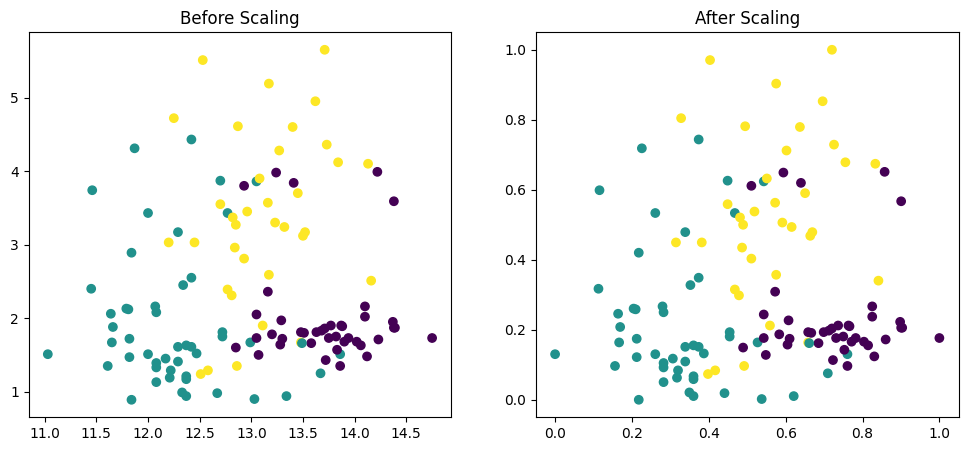

In [29]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

## Step 7 — Compare the distributions

The plots below overlay/compare the KDE of each feature before and after scaling.

* The **combined** plot shows the real benefit: two curves that previously sat on incomparable axes now
  occupy the same 0 – 1 window and can be read side by side.
* The **per-feature** plots make the key point: **the curve shape does not change — only the numbers on
  the x-axis do.**

Normalization does *not* make data Gaussian. `Malic acid` is right-skewed before scaling and just as
right-skewed after. If you need symmetric, bell-shaped features, use a log transform or
`PowerTransformer` (Box-Cox / Yeo-Johnson) instead — and note that a transform like that is applied
*before* scaling, not instead of it.

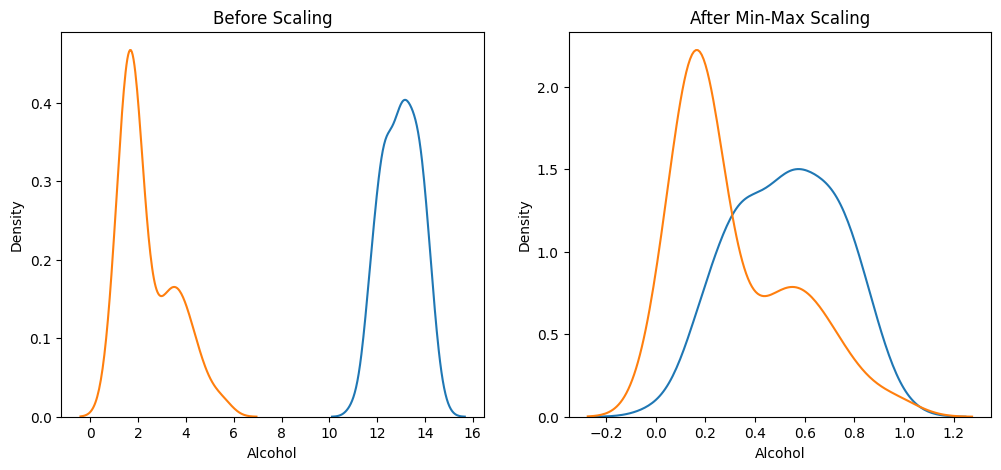

In [30]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Min-Max Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

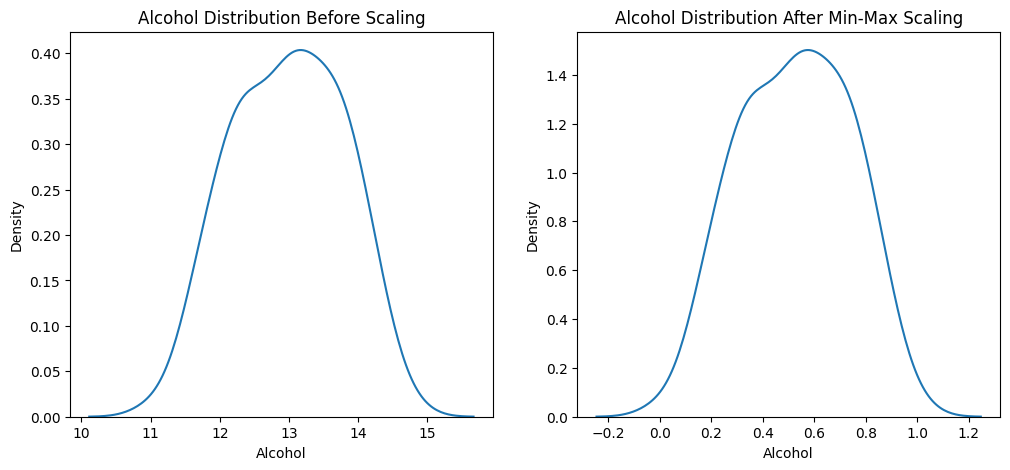

In [31]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Min-Max Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

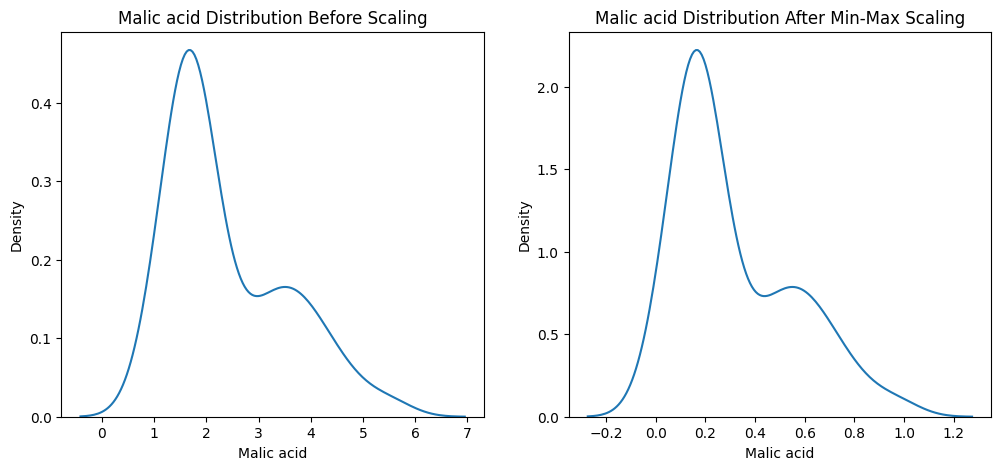

In [32]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Min-Max Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

---

# Summary — Normalization at a glance

| Question | Answer |
|---|---|
| **What does it do?** | Rescales each column into a fixed range, by default [0, 1]. |
| **Formula** | $x_{scaled} = \dfrac{x - x_{min}}{x_{max} - x_{min}}$ |
| **Output range** | Bounded — exactly [0, 1] on the training data. |
| **Why do we need it?** | Puts features with different units on one common, bounded scale so distance-based and gradient-based algorithms are not dominated by the largest-magnitude feature. |
| **When to use it?** | KNN, K-Means and other distance-based models; neural networks; image pixels (0–255 → 0–1); data with known hard bounds; non-Gaussian distributions. |
| **When NOT to use it?** | When the data contains outliers (use `StandardScaler` or `RobustScaler`), or with tree-based models (Decision Tree, Random Forest, XGBoost) and Naive Bayes, which are scale-invariant. |
| **Does it change the distribution shape?** | No. Skew, modes and relative spacing are all preserved. |
| **Outlier behaviour** | Very poor — `x_min`/`x_max` are single data points, so one extreme value crushes everything else into a tiny band. |

### Normalization vs Standardization

| | Normalization (`MinMaxScaler`) | Standardization (`StandardScaler`) |
|---|---|---|
| Formula | $(x - x_{min})/(x_{max} - x_{min})$ | $(x - \mu)/\sigma$ |
| Result | bounded in [0, 1] | mean 0, std 1 |
| Uses | min & max (two points only) | mean & std (all points) |
| Outlier sensitivity | Severe | Moderate |
| Best for | Known bounded data, image pixels, neural net inputs | Gaussian-ish data, PCA/LDA, linear models, SVM, and most classical ML |

There is no universally correct choice: if you are unsure, try both inside a cross-validation loop and
let the validation score decide. Standardization is covered in day07.

### The golden rule
> `fit` on **train only**, `transform` on **train and test**. Never fit the scaler on the test set,
> and never scale before splitting.